In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import re

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent.parent))
from config1 import CLASSIFICATION_DATA


### Getting training history

In [3]:
plogs = CLASSIFICATION_DATA / "3.TRAINING_HISTORY"
p_fig = CLASSIFICATION_DATA / "figures" 

In [ ]:
li_log_i = list(sorted([el for el in os.listdir(plogs) if re.search(r".csv", el)]))
print(li_log_i)

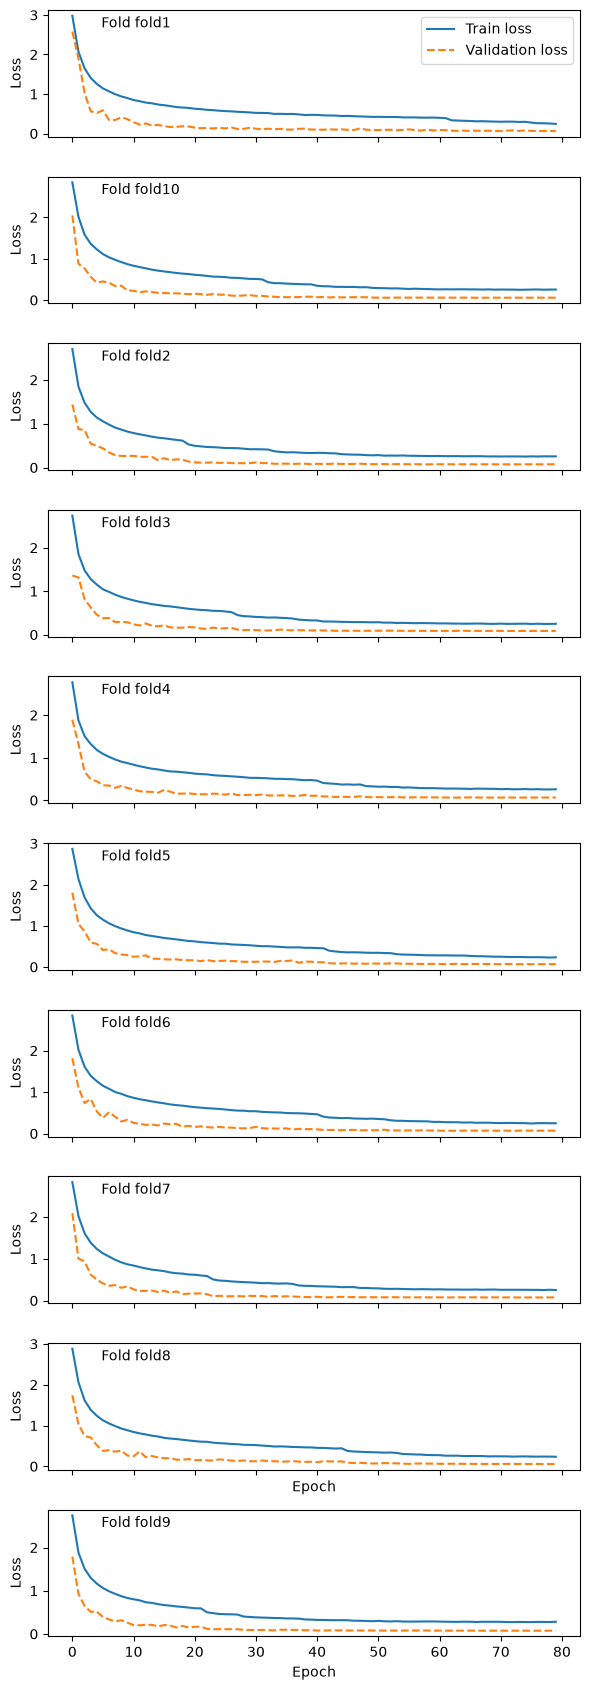

In [12]:
fig, axes = plt.subplots(nrows=10,ncols=1,figsize=(6, 17),sharex=True)

axes = axes.flatten()


for file_i, ax in zip(li_log_i, axes):


    fold = file_i.split("_")[-1].replace(".csv", "")
    # print(f"\nFold {fold}")

    history = pd.read_csv(plogs / file_i)

    ax.plot(history['loss'], label='Train loss')
    ax.plot(history['val_loss'], '--', label='Validation loss')

    ax.text(0.1, 0.95, f'Fold {fold.replace("cval", "")}',transform=ax.transAxes,va='top',ha='left')

    ax.set_ylabel("Loss")

axes[0].legend(loc='upper right')

for ax in axes[-2:]:  # bottom row
    ax.set_xlabel("Epoch")

plt.tight_layout()

# plt.savefig(p_fig + f"loss_curves.pdf",bbox_inches='tight')

plt.show()

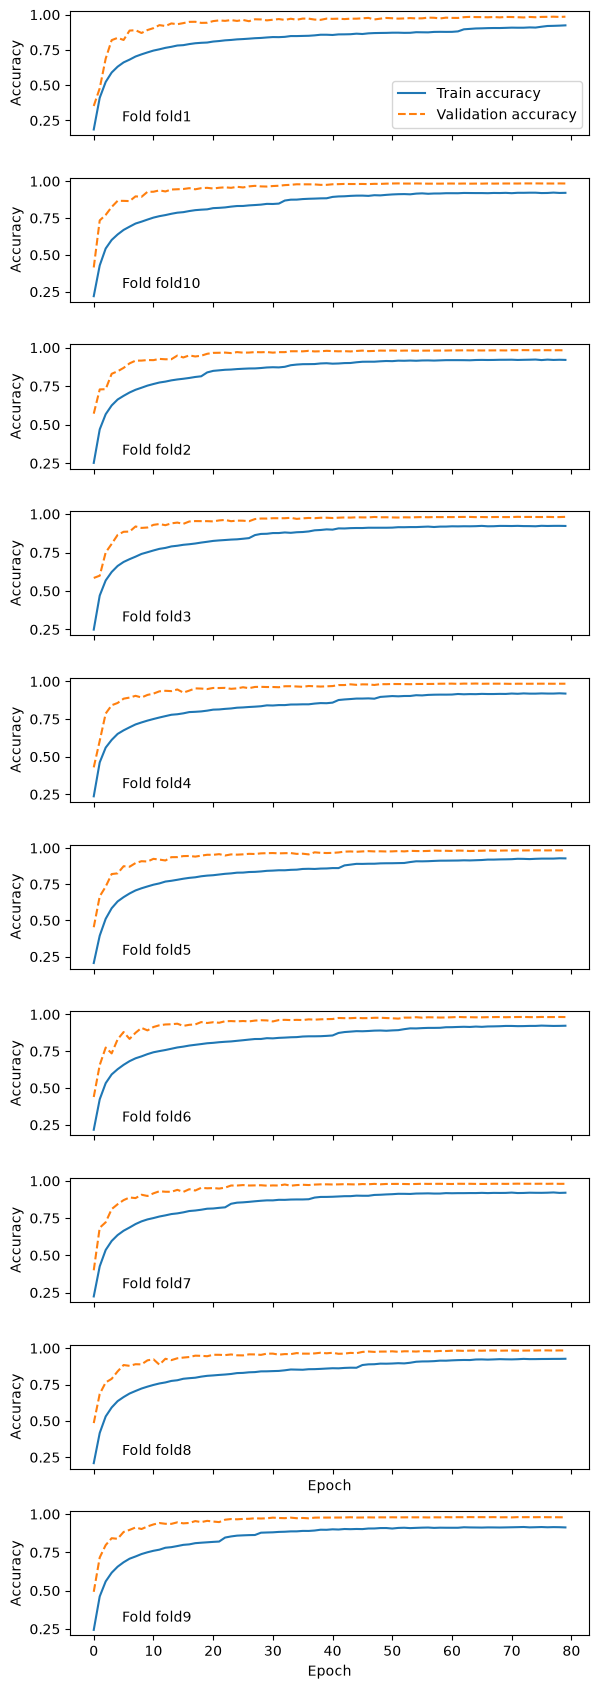

In [13]:
fig, axes = plt.subplots(nrows=10,ncols=1,figsize=(6, 17),sharex=True)

axes = axes.flatten()


for file_i, ax in zip(li_log_i, axes):

    fold = file_i.split("_")[-1].replace(".csv", "")
    # print(f"\nFold {fold}")

    history = pd.read_csv(plogs / file_i)

    ax.plot(history['accuracy'], label='Train accuracy')
    ax.plot(history['val_accuracy'], '--', label='Validation accuracy')

    ax.text(0.1, 0.2, f'Fold {fold.replace("cval", "")}',transform=ax.transAxes,va='top',ha='left')

    ax.set_ylabel("Accuracy")

axes[0].legend(loc='lower right')

for ax in axes[-2:]:  # bottom row
    ax.set_xlabel("Epoch")

plt.tight_layout()

# plt.savefig(p_fig + f"accuracy_curves.pdf",bbox_inches='tight')

plt.show()